In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/ai_job_dataset.csv")

In [ ]:
df.shape

(15000, 19)

In [ ]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [ ]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [ ]:
df.isnull().sum()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


In [ ]:
df.duplicated().sum()

np.int64(0)

check unique values

In [ ]:
for col in df.columns:
    print(col, ":", df[col].nunique())

job_id : 15000
job_title : 20
salary_usd : 14315
salary_currency : 3
experience_level : 4
employment_type : 4
company_location : 20
company_size : 3
employee_residence : 20
remote_ratio : 3
required_skills : 13663
education_required : 4
years_experience : 20
industry : 15
posting_date : 486
application_deadline : 543
job_description_length : 2000
benefits_score : 51
company_name : 16


Identify Columns by Type

In [ ]:
#Numerical
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['salary_usd', 'remote_ratio', 'years_experience',
       'job_description_length', 'benefits_score'],
      dtype='object')

In [ ]:
#categorical
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['job_id', 'job_title', 'salary_currency', 'experience_level',
       'employment_type', 'company_location', 'company_size',
       'employee_residence', 'required_skills', 'education_required',
       'industry', 'posting_date', 'application_deadline', 'company_name'],
      dtype='object')

# Univariate Analysis

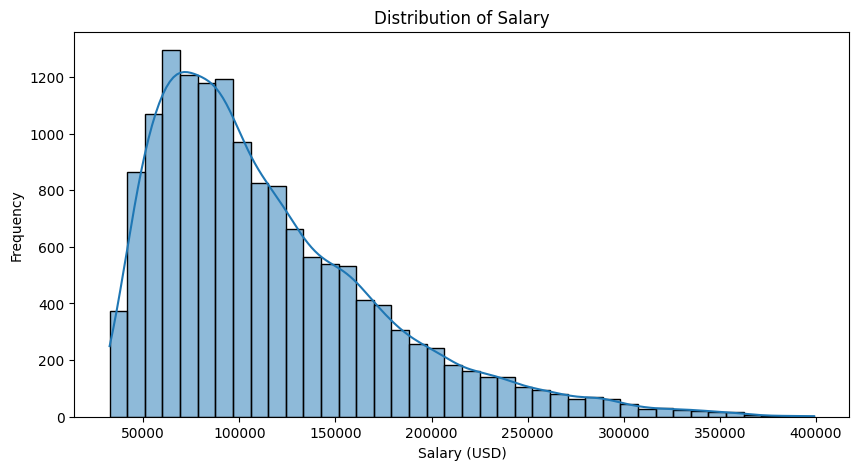

In [ ]:
#Salary
plt.figure(figsize=(10,5))
sns.histplot(
    df['salary_usd'],
    bins=40,
    kde=True

)
plt.title("Distribution of Salary")
plt.xlabel("Salary (USD)")
plt.ylabel("Frequency")
plt.show()

This is a right skewed distribution

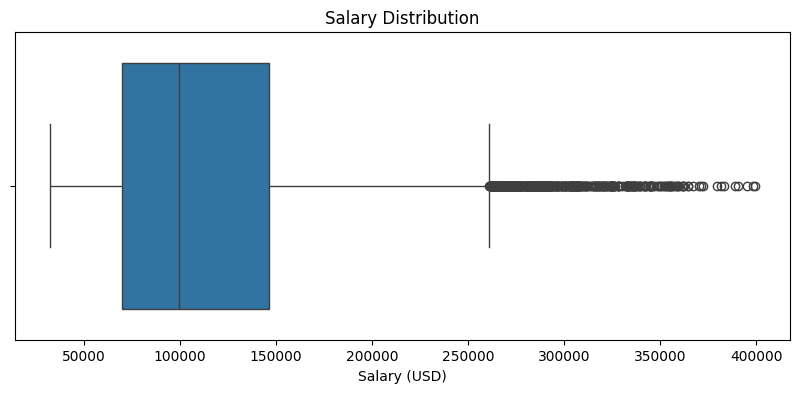

In [ ]:
#Salary
plt.figure(figsize=(10,4))
sns.boxplot(x=df['salary_usd'])
plt.title("Salary Distribution")
plt.xlabel("Salary (USD)")
plt.show()

here there are outliers, but we not automatically remove them because a AI research person can have more highest salary

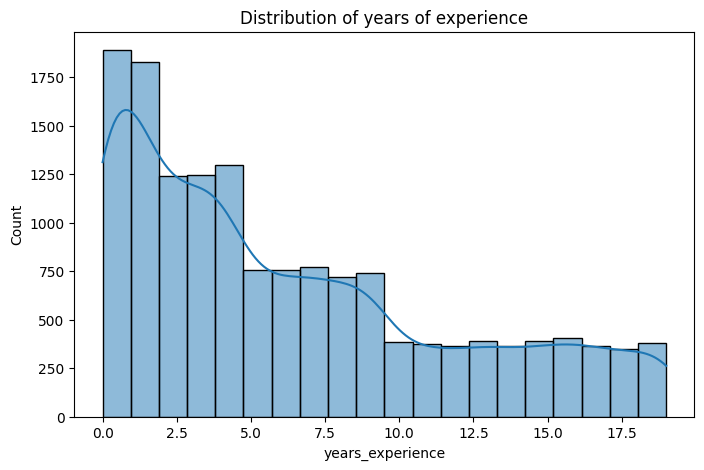

In [ ]:
#Years of experience
plt.figure(figsize=(8,5))
sns.histplot(
    df['years_experience'],
    bins=20,
    kde=True
)
plt.title("Distribution of years of experience")
plt.show()

In my dataset there 0-19 years experience values

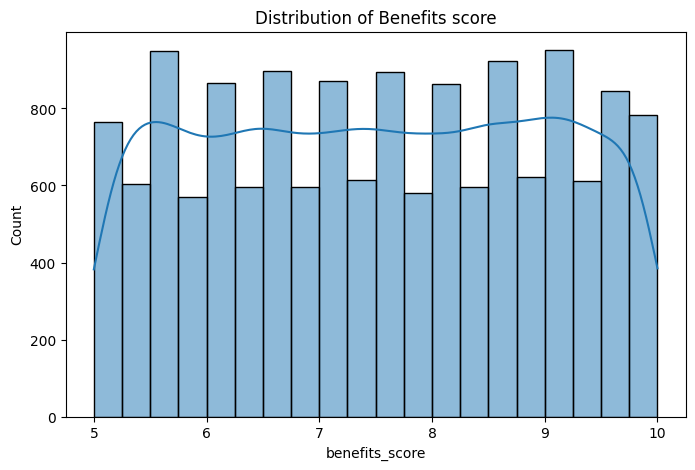

In [ ]:
#Benefits Score
plt.figure(figsize=(8,5))
sns.histplot(
    df['benefits_score'],
    bins=20,
    kde=True
)
plt.title("Distribution of Benefits score")
plt.show()

Text(0.5, 1.0, 'Job descriptiom lenth distribution')

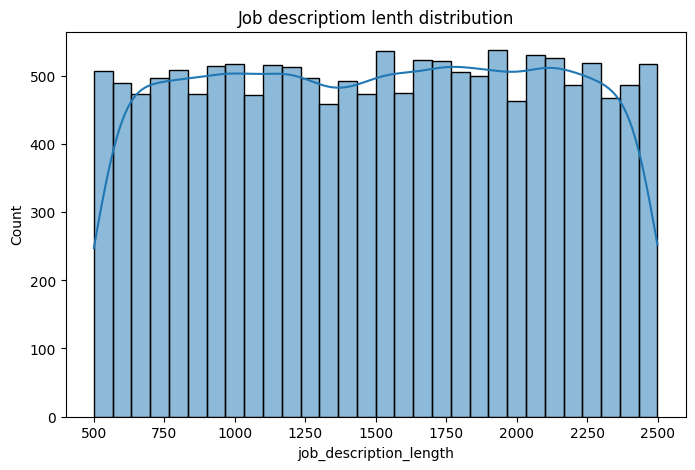

In [ ]:
#job description length
plt.figure(figsize=(8,5))
sns.histplot(
    df['job_description_length'],
    bins=30,
    kde=True
)
plt.title("Job descriptiom lenth distribution")

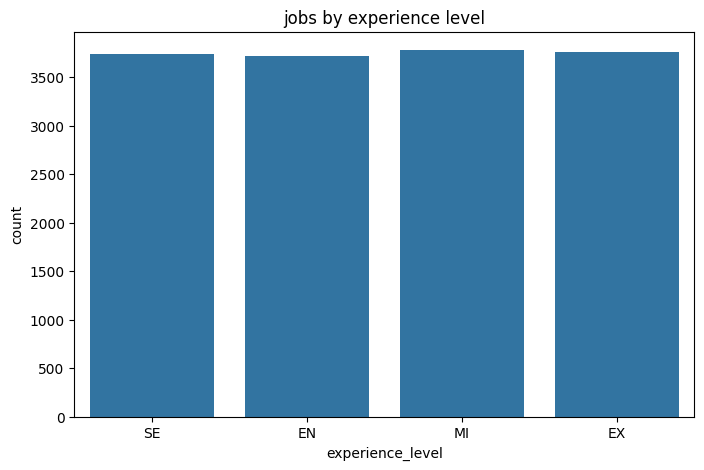

In [ ]:
#Experience level
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='experience_level',
)
plt.title("jobs by experience level")
plt.show()

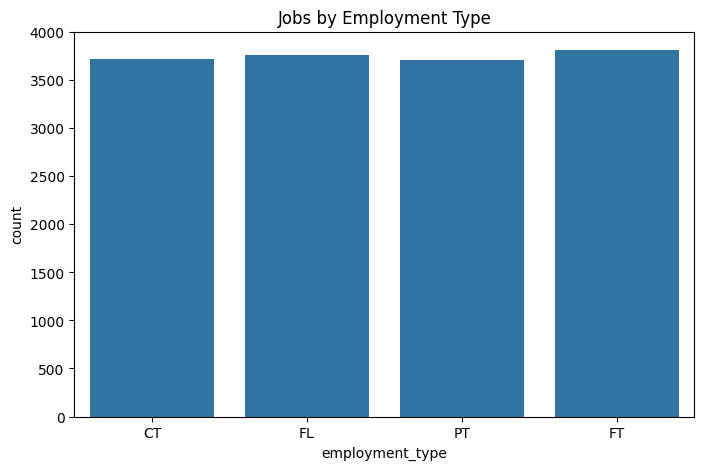

In [ ]:
#Employment type
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='employment_type'
)
plt.title("Jobs by Employment Type")
plt.show()

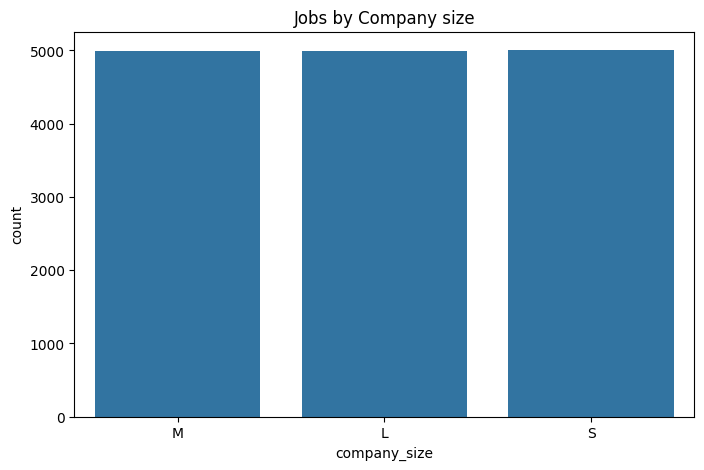

In [ ]:
#company size
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='company_size'
)
plt.title("Jobs by Company size")
plt.show()

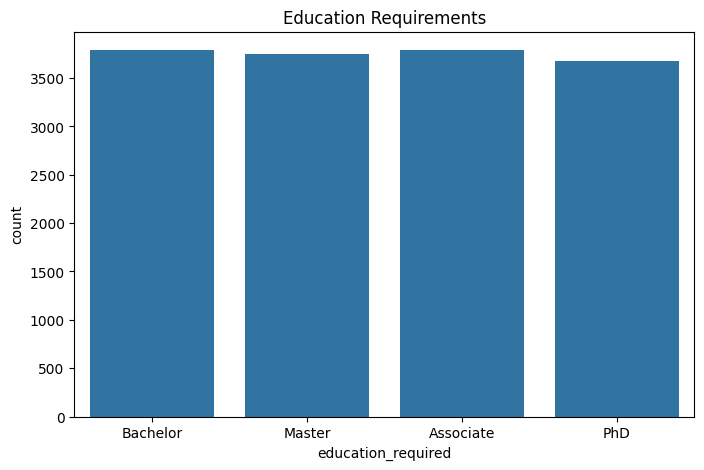

In [ ]:
#Education Required
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='education_required'
)
plt.title("Education Requirements")
plt.show()

this explains how many job postings require which education

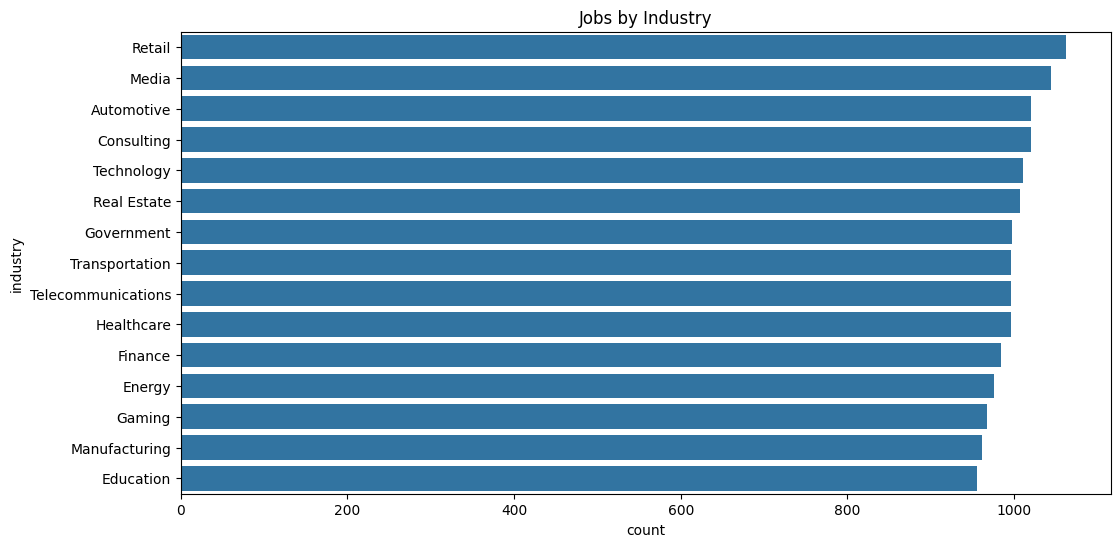

In [ ]:
#industry distribution
plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    y='industry',
    order=df['industry'].value_counts().index
)
plt.title("Jobs by Industry")
plt.show()

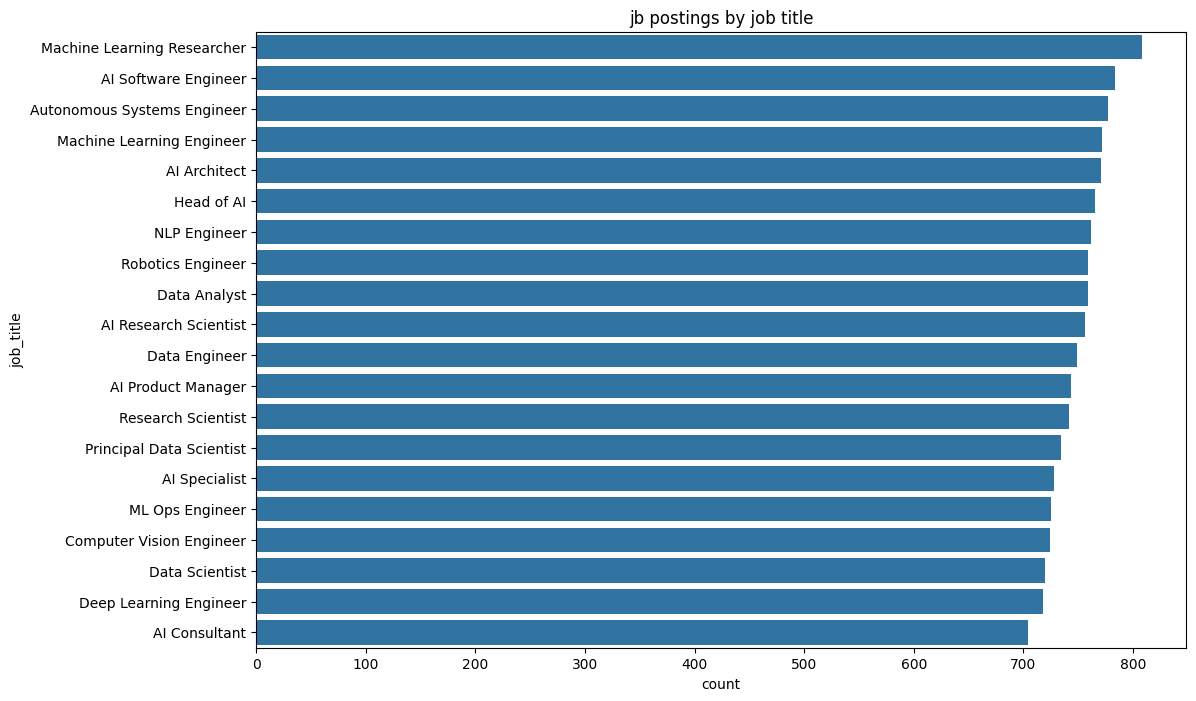

In [ ]:
#job title distribution
plt.figure(figsize=(12,8))
sns.countplot(
    data=df,
    y='job_title',
    order=df['job_title'].value_counts().index
)
plt.title("jb postings by job title")
plt.show()

#Bivariate Analysis

Text(0.5, 1.0, 'salary vs experience level')

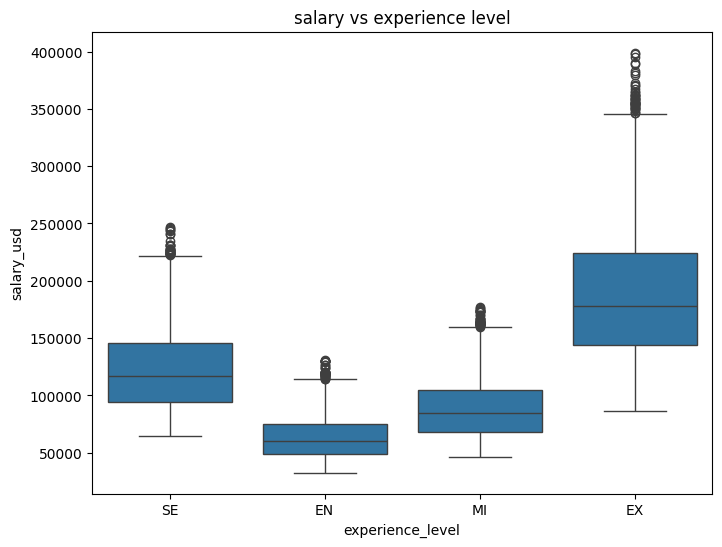

In [ ]:
#salary vs Experience level
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='experience_level',
    y='salary_usd'
)
plt.title("salary vs experience level")

In [ ]:
df.groupby('experience_level')['salary_usd'].agg(
    ['count','mean','median']
).sort_values('mean', ascending=False)

,count,mean,median
experience_level,,,
EX,3760,187723.647340,177512.0
SE,3741,122187.657845,116907.0
MI,3781,87955.471833,84641.0
EN,3718,63133.377084,60373.5


#insight
Executive-level positions have the highest average salary, followed by senior, mid-level, and entry-level roles. This indicates that experience level is one of the strongest salary determinants.

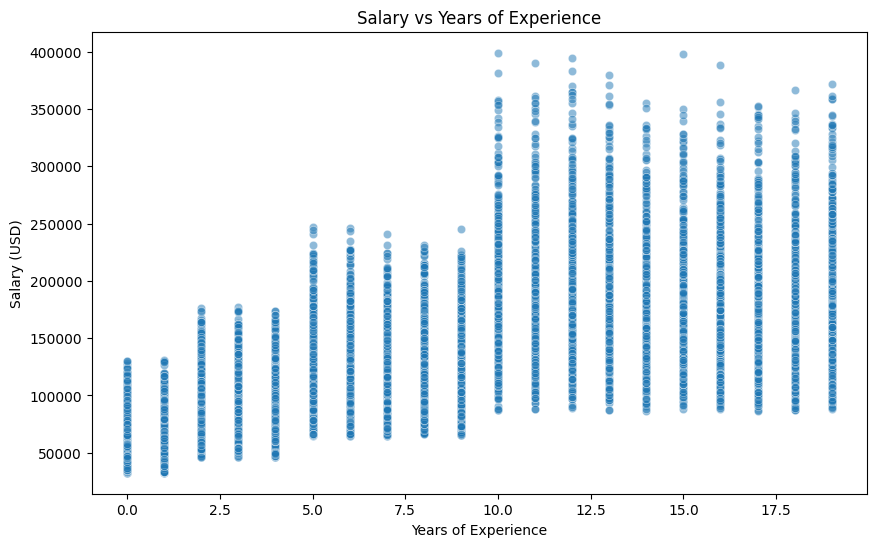

In [ ]:
#Salary vs Years of Experience
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='years_experience',
    y='salary_usd',
    alpha=0.5
)

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")

plt.show()

In [ ]:
df[['years_experience', 'salary_usd']].corr()

,years_experience,salary_usd
years_experience,1.000000,0.737556
salary_usd,0.737556,1.000000


Very important insight

Years of experience has a strong positive relationship with salary. The correlation of approximately 0.74 indicates that salary generally increases as required experience increases.

years of experience is one of the most important model feature

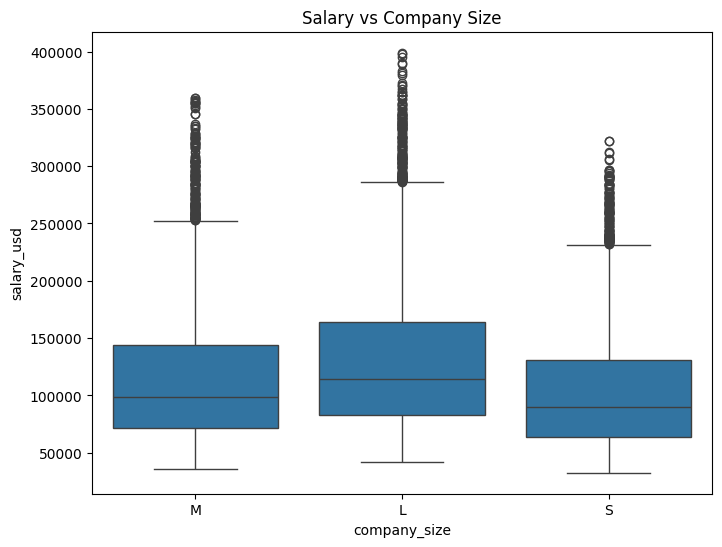

In [ ]:
#Salary vs Company Size
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='company_size',
    y='salary_usd'
)

plt.title("Salary vs Company Size")

plt.show()

Insight

Larger companies tend to offer higher salaries than medium and small companies. Large-company jobs have an average salary approximately $28K higher than small-company jobs.

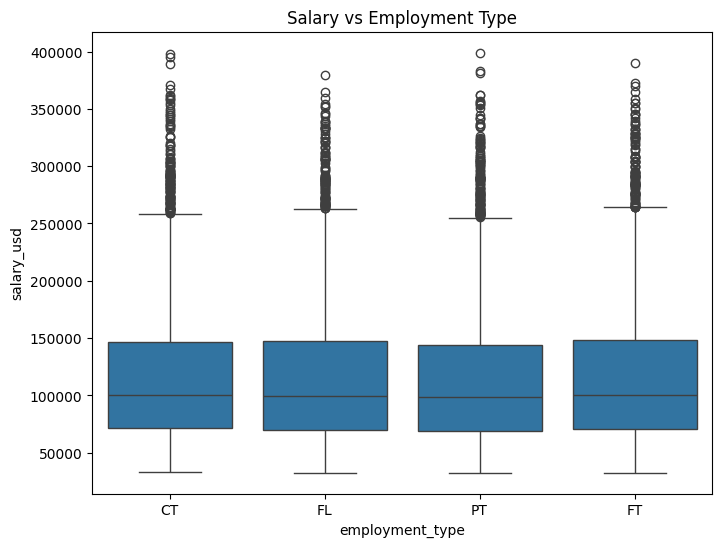

In [ ]:
#Salary vs Employment Type
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='employment_type',
    y='salary_usd'
)

plt.title("Salary vs Employment Type")

plt.show()

Insight

Employment type has relatively little impact on salary compared with experience level and years of experience.

This is an important finding because not every variable needs to be a strong predictor.

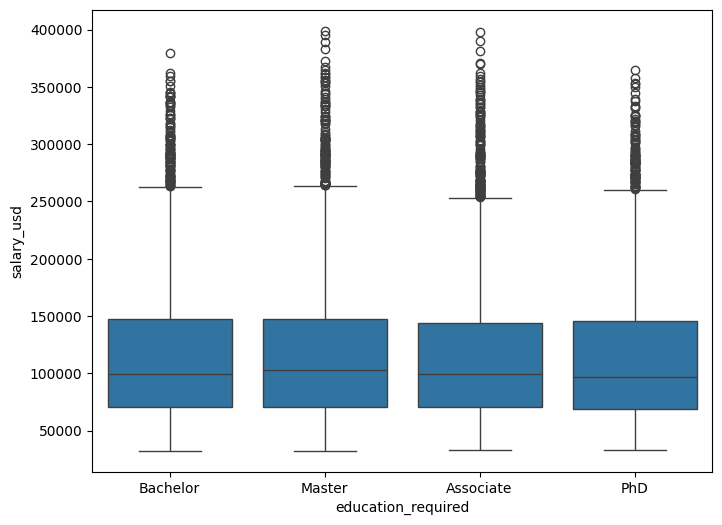

In [ ]:
#Salary vs Education
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='education_required',
    y='salary_usd'
)

plt.show()

Insight

The differences are relatively small.

In this dataset, education level appears to have a much weaker relationship with salary than experience level.

This is actually a valuable business insight.

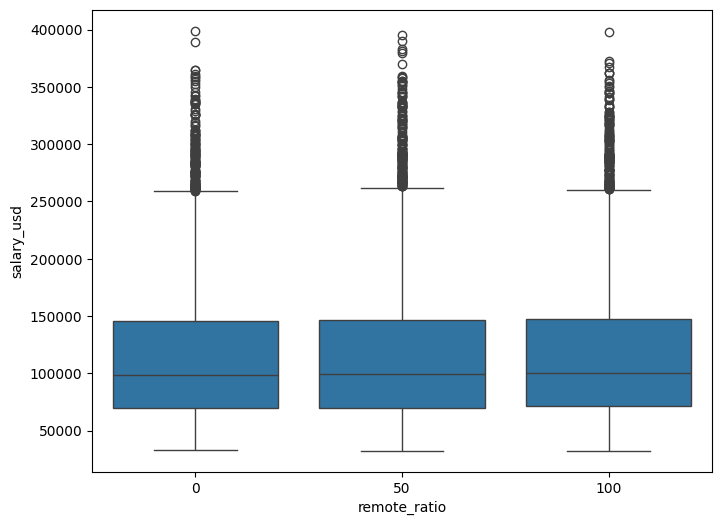

In [ ]:
#Salary vs Remote Ratio
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='remote_ratio',
    y='salary_usd'
)

plt.show()

In [ ]:
df.groupby('remote_ratio')['salary_usd'].mean()

,salary_usd
remote_ratio,
0,114140.231133
50,115776.806793
100,116160.545935


Insight

Remote work percentage has only a weak relationship with salary in this dataset. Fully remote positions have slightly higher average salaries, but the difference is relatively small.

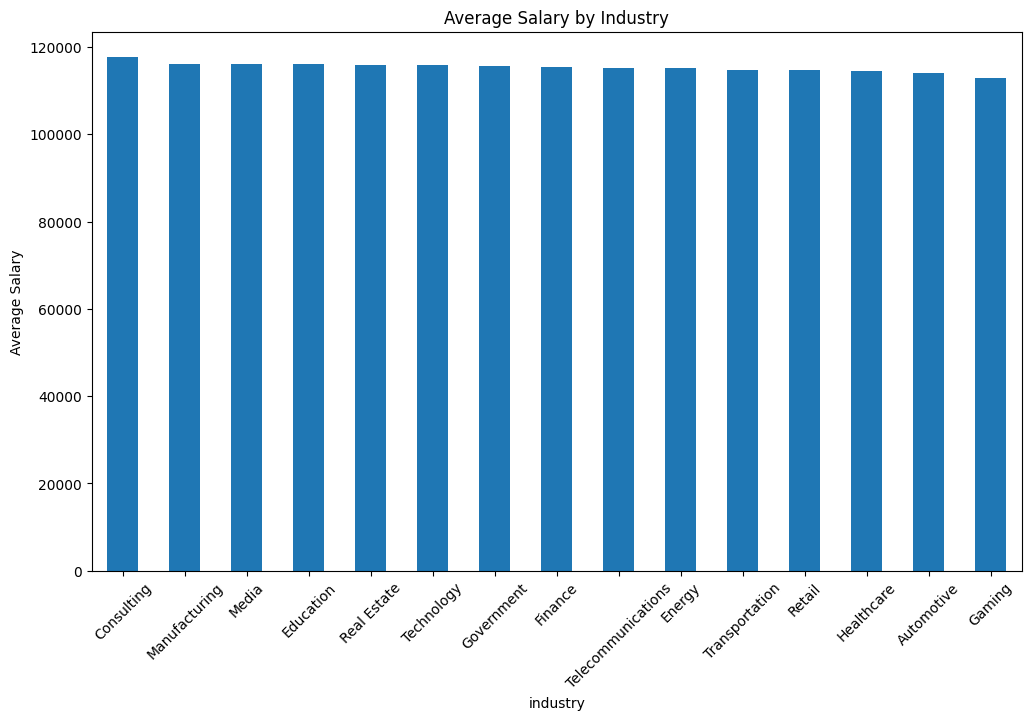

In [ ]:
#Salary vs Industry
industry_salary = (
    df.groupby('industry')['salary_usd']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,7))

industry_salary.plot(kind='bar')

plt.title("Average Salary by Industry")
plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

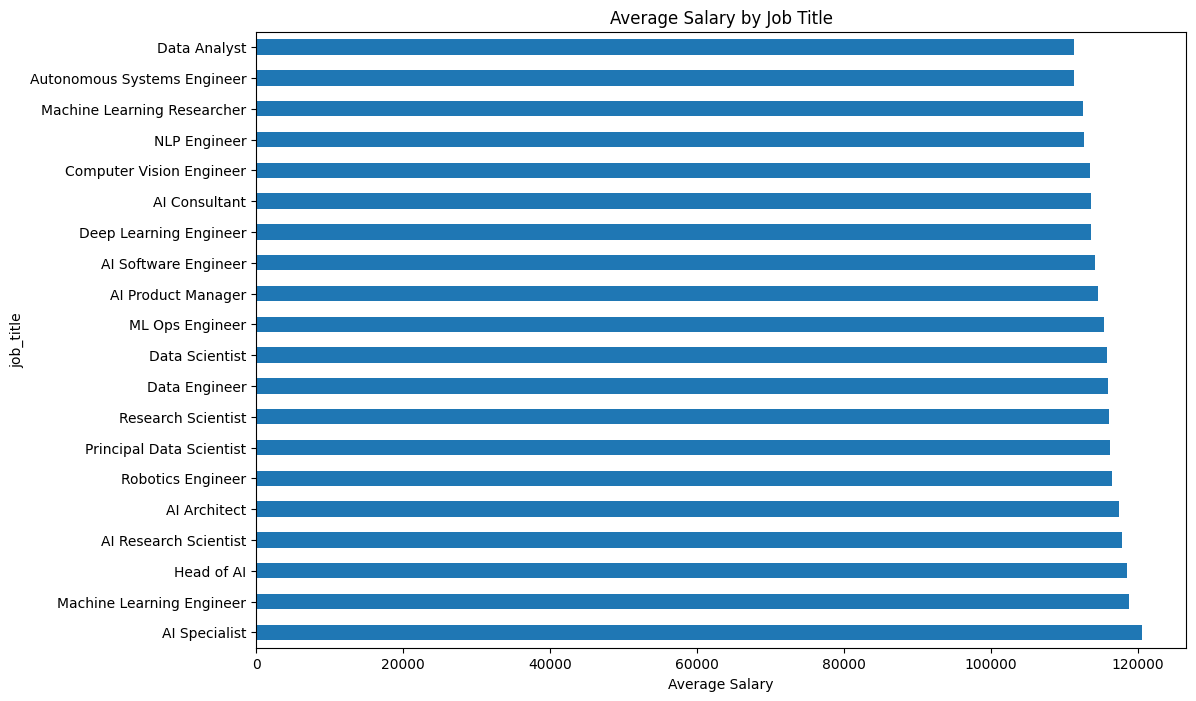

In [ ]:
#Salary vs Job Title
job_salary = (
    df.groupby('job_title')['salary_usd']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

job_salary.plot(kind='barh')

plt.title("Average Salary by Job Title")
plt.xlabel("Average Salary")

plt.show()

In [ ]:
df.groupby('job_title')['salary_usd'].mean().sort_values(ascending=False)

,salary_usd
job_title,
AI Specialist,120570.758242
Machine Learning Engineer,118827.919689
Head of AI,118542.968627
AI Research Scientist,117897.925926
AI Architect,117436.513619
Robotics Engineer,116470.793149
Principal Data Scientist,116305.219346
Research Scientist,116066.502695
Data Engineer,115970.720961


Insight

Job title contributes to salary differences, although experience level and years of experience show stronger relationships with salary.

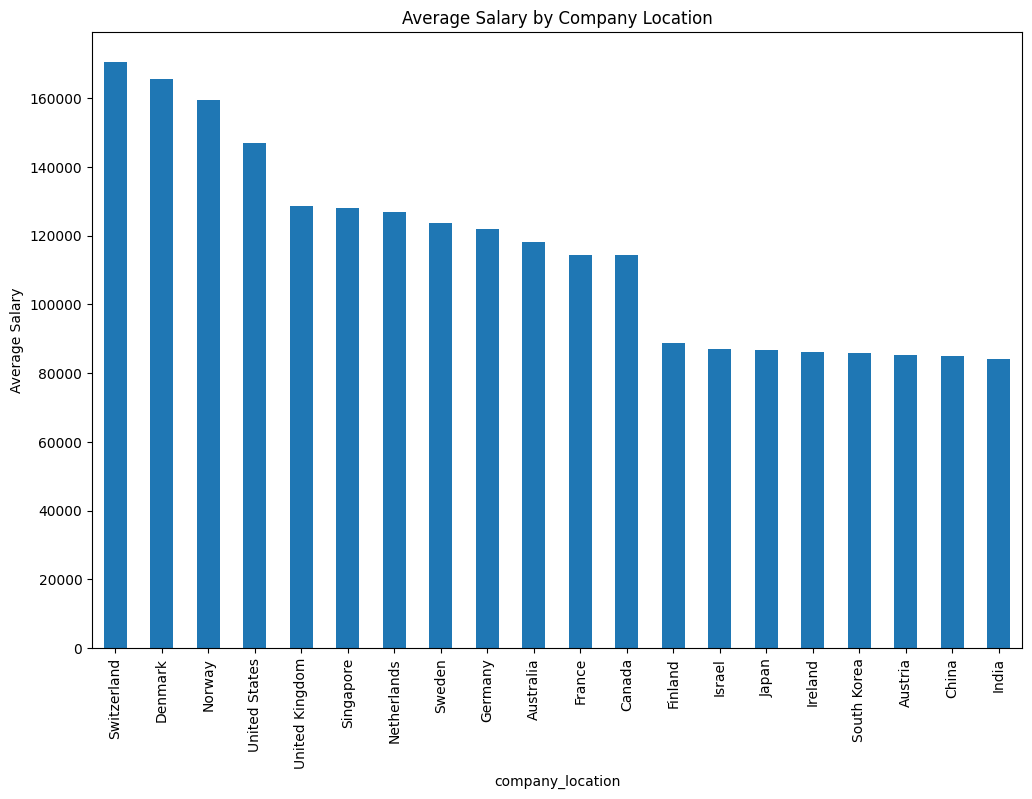

In [ ]:
#Salary vs Company Location
location_salary = (
    df.groupby('company_location')['salary_usd']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

location_salary.plot(kind='bar')

plt.title("Average Salary by Company Location")
plt.ylabel("Average Salary")

plt.show()

In [ ]:
df.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False)

,salary_usd
company_location,
Switzerland,170639.085791
Denmark,165652.249357
Norway,159490.533981
United States,146833.045580
United Kingdom,128720.186557
Singapore,128004.035340
Netherlands,126750.451436
Sweden,123559.753989
Germany,121810.143735


Insight

Company location appears to be a major salary driver. Switzerland, Denmark, Norway and the United States have substantially higher average salaries than many other locations.

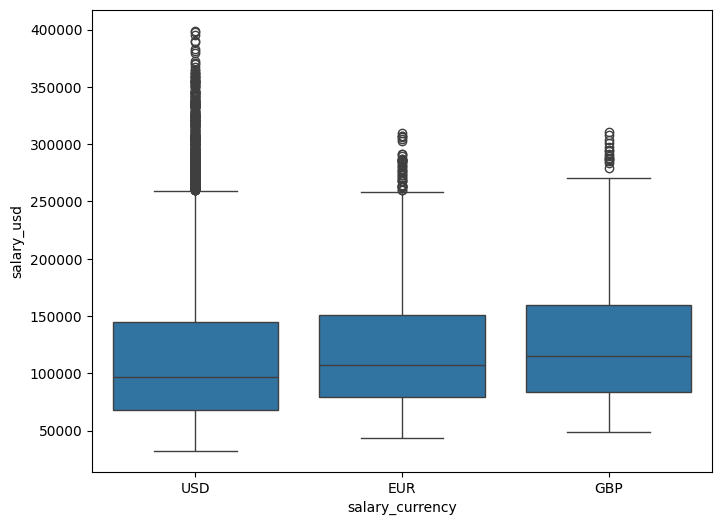

In [ ]:
#Salary vs Salary Currency
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='salary_currency',
    y='salary_usd'
)
plt.show()

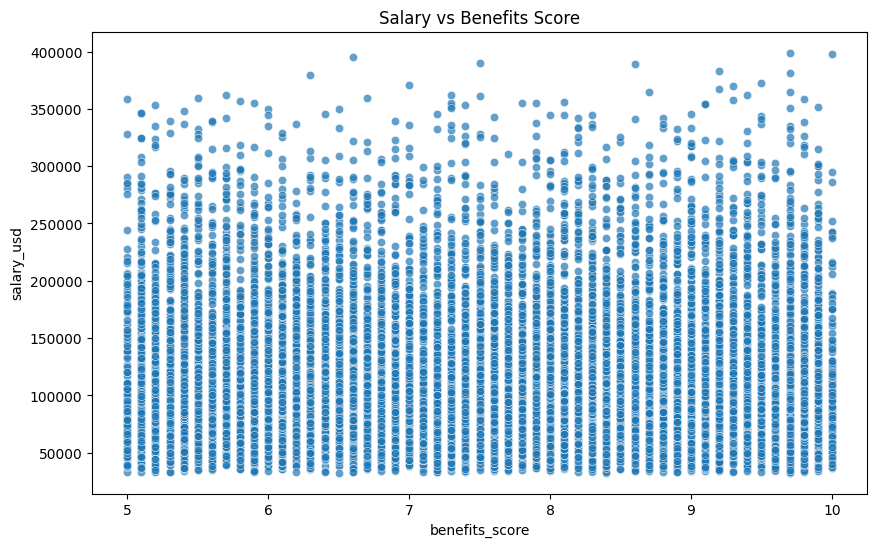

In [ ]:
#Salary vs Benefits Score
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='benefits_score',
    y='salary_usd',
    alpha=0.7
)

plt.title("Salary vs Benefits Score")

plt.show()

In [ ]:
df[['benefits_score', 'salary_usd']].corr()

,benefits_score,salary_usd
benefits_score,1.000000,0.000985
salary_usd,0.000985,1.000000


Insight

Benefits score has almost no linear relationship with salary in this dataset. Therefore, benefits are not a major salary predictor here.

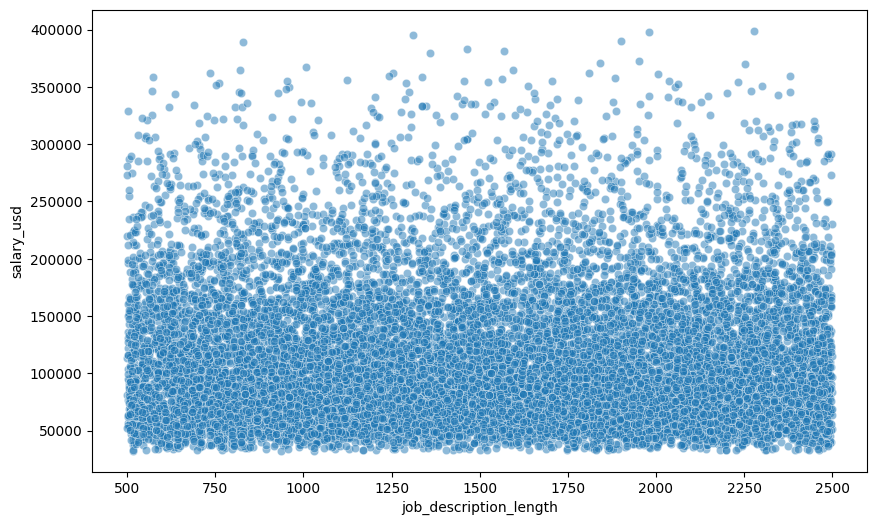

In [ ]:
#Salary vs Job Description Length
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='job_description_length',
    y='salary_usd',
    alpha=0.5
)

plt.show()

In [ ]:
df[['job_description_length','salary_usd']].corr()

,job_description_length,salary_usd
job_description_length,1.000000,-0.009092
salary_usd,-0.009092,1.000000


insight

job description length has virtually no linear relationship with salary

#correlation matrix

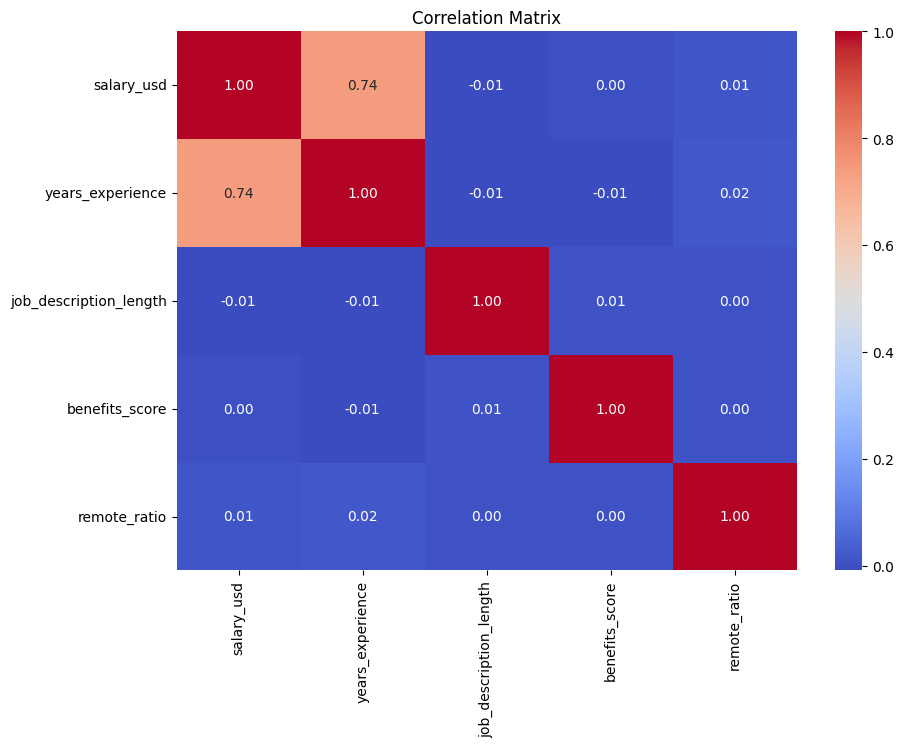

In [ ]:
numeric_cols = [
    'salary_usd',
    'years_experience',
    'job_description_length',
    'benefits_score',
    'remote_ratio'
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

#Multivariate Analysis


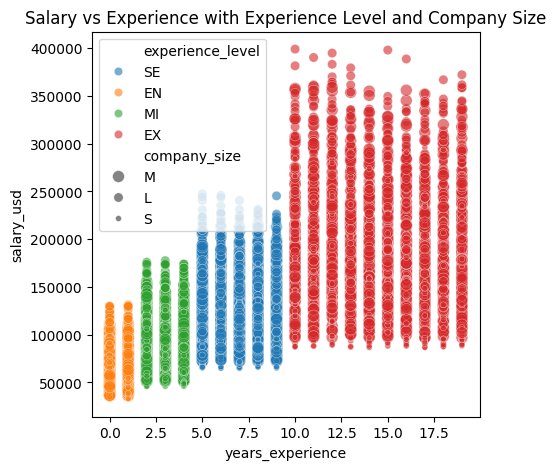

In [ ]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    data=df,
    x='years_experience',
    y='salary_usd',
    hue='experience_level',
    size='company_size',
    alpha=0.6
)

plt.title("Salary vs Experience with Experience Level and Company Size")

plt.show()

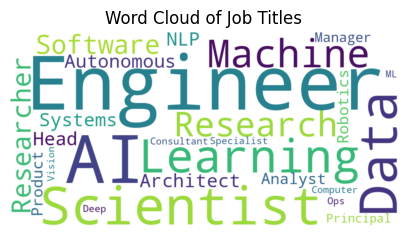

In [ ]:
from wordcloud import WordCloud
job_title_text = ' '.join(
    df['job_title'].dropna().astype(str)
)

wordcloud_jobtitle = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    collocations=False
).generate(job_title_text)

plt.figure(figsize=(5,5))
plt.imshow(wordcloud_jobtitle, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Titles')
plt.show()

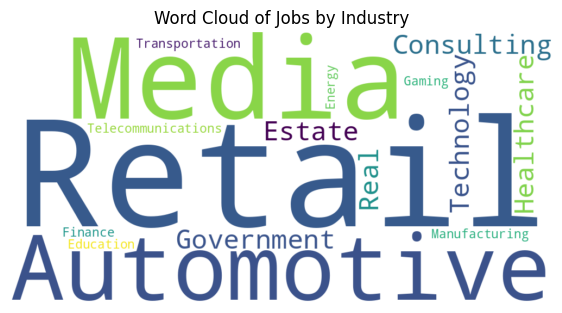

In [ ]:
industry_text = ' '.join(
    df['industry'].dropna().astype(str)
)

wordcloud_industry = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    collocations=False
).generate(industry_text)

plt.figure(figsize=(7,7))
plt.imshow(wordcloud_industry, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Jobs by Industry')
plt.show()

#remove outliers

In [ ]:
Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Lower bound: -44163.375
Upper bound: 260751.625


In [ ]:
df = df[
    (df['salary_usd'] >= lower_bound) &
    (df['salary_usd'] <= upper_bound)
]

Feature Selection

Drop job_id

job_id is just an identifier.

It has 15,000 unique values for 15,000 records.

It provides no useful information about salary

In [ ]:
df = df.drop('job_id', axis=1)

Important insight

job_id should not be used as a predictive feature because it is a unique identifier rather than a meaningful business characteristic.

#Insights

1.Years of Experience Has a Strong Impact on Salary
2.Experience Level Creates Major Salary Differences
3.Company Size Is Associated with Salary
4.Company Location Has a Significant Relationship with Salary
5.Employment Type Has a Relatively Small Impact on Salary
6.Education Level Has a Relatively Weak Relationship with Salary
7.Remote Work Ratio Has a Limited Impact on Salary
8.Benefits Score Has Almost No Relationship with Salary
9.Job Description Length Does Not Predict Salary